In [1]:
#Step 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [3]:
#Step 2: Load Dataset

In [4]:
df = pd.read_csv("retail_sales.csv")

In [5]:
#View first rows

In [6]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [7]:
#Dataset information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [9]:
#Dataset shape

In [10]:
df.shape

(1000, 9)

In [11]:
#Column names

In [12]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [13]:
#Step 3: Initial Data Inspection

In [14]:
#Check data types

In [15]:
df.dtypes

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

In [16]:
#Summary

In [17]:
df.describe(include='all')

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000,1000,1000.00000,1000,1000.000000,1000.000000,1000.000000
unique,NaN,345,1000,2,NaN,3,NaN,NaN,NaN
top,NaN,2023-05-16,CUST001,Female,NaN,Clothing,NaN,NaN,NaN
freq,NaN,11,1,510,NaN,351,NaN,NaN,NaN
mean,500.500000,NaN,NaN,NaN,41.39200,NaN,2.514000,179.890000,456.000000
std,288.819436,NaN,NaN,NaN,13.68143,NaN,1.132734,189.681356,559.997632
min,1.000000,NaN,NaN,NaN,18.00000,NaN,1.000000,25.000000,25.000000
25%,250.750000,NaN,NaN,NaN,29.00000,NaN,1.000000,30.000000,60.000000
50%,500.500000,NaN,NaN,NaN,42.00000,NaN,3.000000,50.000000,135.000000
75%,750.250000,NaN,NaN,NaN,53.00000,NaN,4.000000,300.000000,900.000000


In [18]:
#Check missing values

In [19]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [20]:
#Missing value percentage

In [21]:
missing = (df.isnull().sum()/len(df))*100

missing.sort_values(ascending=False)

Transaction ID      0.0
Date                0.0
Customer ID         0.0
Gender              0.0
Age                 0.0
Product Category    0.0
Quantity            0.0
Price per Unit      0.0
Total Amount        0.0
dtype: float64

In [22]:
#Step 4: Duplicate Records

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
#Remove duplicates

In [26]:
df = df.drop_duplicates()

In [27]:
#Step 5: Handle Missing Values

In [28]:
#Numerical Columns

In [29]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\MANJUNATH\AppData\Local\Temp\ipykernel_27476\3551297251.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [30]:
#Categorical Columns

In [31]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\MANJUNATH\AppData\Local\Temp\ipykernel_27476\2422164989.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [33]:
#Verify

In [34]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [35]:
#Step 6: Convert Date

In [36]:
df['Date'] = pd.to_datetime(df['Date'])

In [37]:
#Create additional columns

In [38]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()
df['Day'] = df['Date'].dt.day

In [40]:
#Step 7: Outlier Detection Using IQR



In [43]:
Q1 = df['Total Amount'].quantile(0.25)
Q3 = df['Total Amount'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

In [44]:
#Find outliers

In [45]:
outliers = df[(df['Total Amount']<lower) |
              (df['Total Amount']>upper)]

outliers.shape

(0, 12)

In [46]:
#Step 8: Remove Outliers

In [47]:
df = df[(df['Total Amount']>=lower) &
        (df['Total Amount']<=upper)]

In [48]:
#Step 9: Save Clean Dataset

In [49]:
df.to_csv("cleaned_retail_sales.csv", index=False)

In [50]:
#Exploratory Data Analysis (EDA)
#1. Sales Distribution

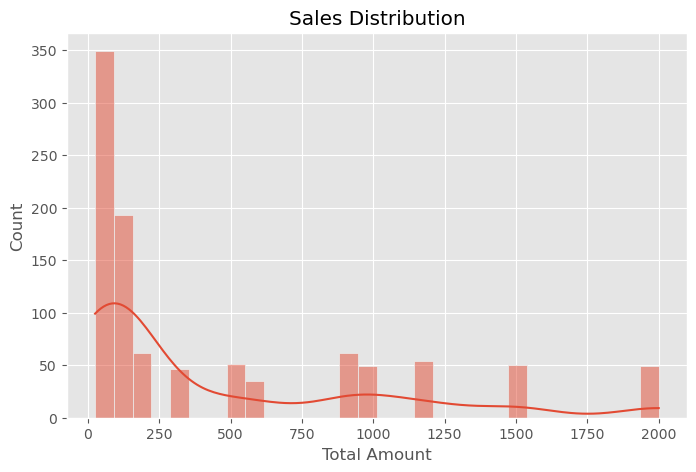

In [52]:
plt.figure(figsize=(8,5))

sns.histplot(df['Total Amount'], bins=30, kde=True)

plt.title("Sales Distribution")

plt.show()

In [53]:
#2. Product Category Sales

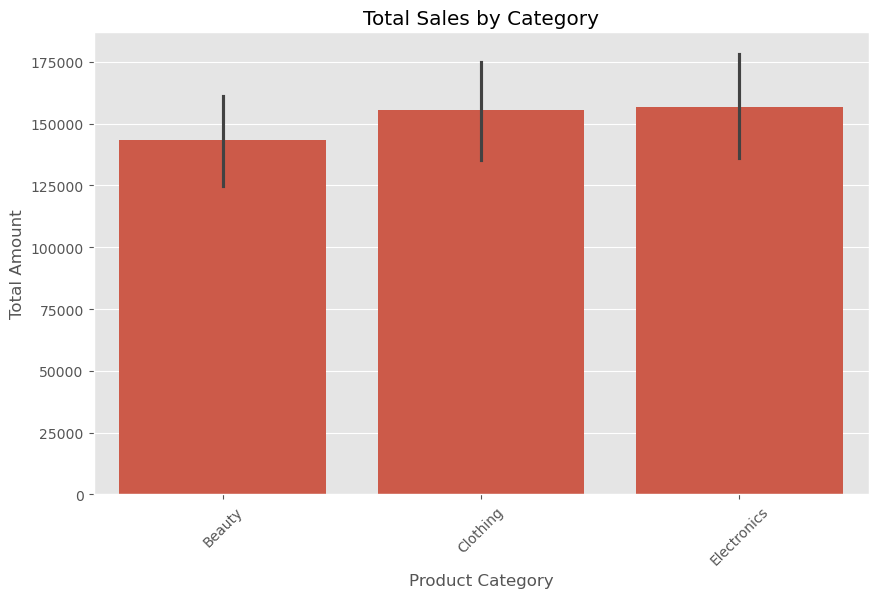

In [54]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='Product Category',
    y='Total Amount',
    estimator=np.sum
)

plt.xticks(rotation=45)

plt.title("Total Sales by Category")

plt.show()

In [55]:
#3. Customer Age Distribution

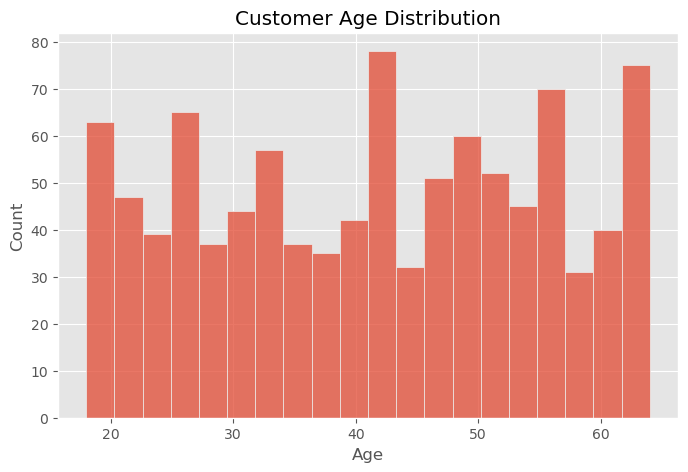

In [56]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20)

plt.title("Customer Age Distribution")

plt.show()

In [57]:
#4. Boxplot for Sales

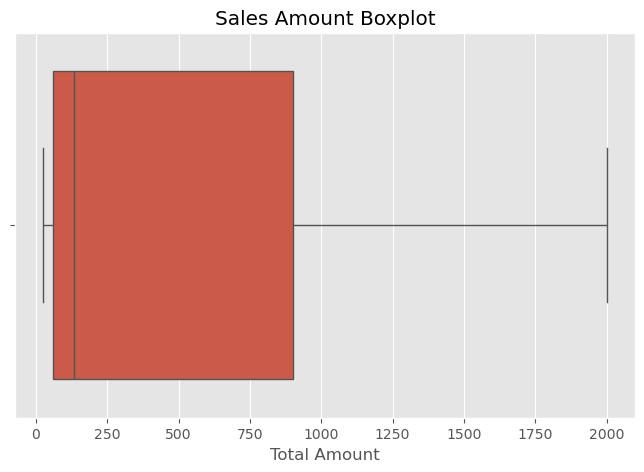

In [59]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Total Amount'])

plt.title("Sales Amount Boxplot")

plt.show()

In [60]:
#5. Monthly Sales Trend

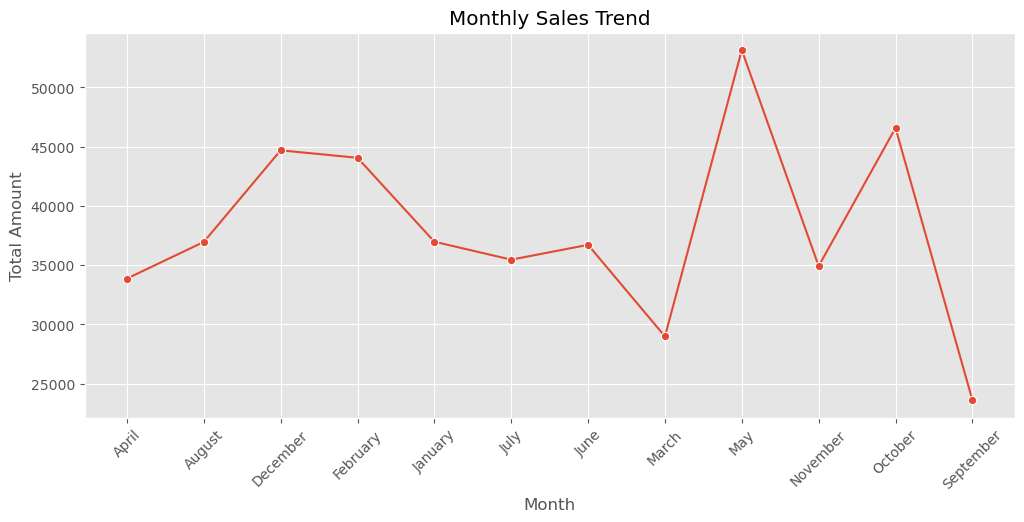

In [61]:
monthly = df.groupby('Month')['Total Amount'].sum().reset_index()

plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly,
    x='Month',
    y='Total Amount',
    marker='o'
)

plt.xticks(rotation=45)

plt.title("Monthly Sales Trend")

plt.show()

In [62]:
#6. Correlation Heatmap

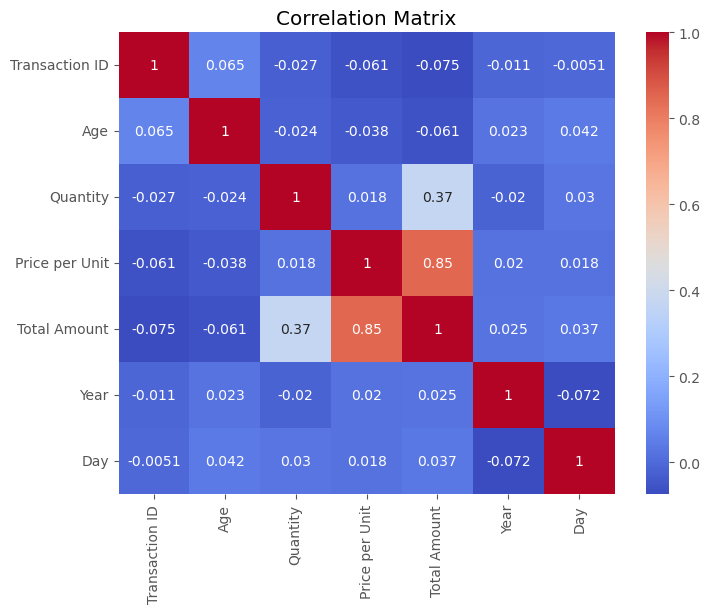

In [63]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

In [64]:
#Summary Statistics

In [65]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount,Year,Day
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000,2023.002000,15.310000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000,2023.000000,1.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000,2023.000000,7.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000,2023.000000,15.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000,2023.000000,23.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000,2024.000000,31.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632,0.044699,8.871674


In [66]:
#Category-wise sales

In [67]:
df.groupby('Product Category')['Total Amount'].agg(['count','sum','mean'])

,count,sum,mean
Product Category,,,
Beauty,307,143515,467.475570
Clothing,351,155580,443.247863
Electronics,342,156905,458.786550


In [68]:
#Average quantity sold

In [69]:
df.groupby('Product Category')['Quantity'].mean()

Product Category
Beauty         2.511401
Clothing       2.547009
Electronics    2.482456
Name: Quantity, dtype: float64